# Brent Oil Forecasting Notebook 3
## STL Decomposition + Baseline + Residual + RoR

## 이 노트북이 답하는 질문
- `baseline -> 잔차 보정 -> 2차 잔차 보정` 구조가 STL 틀 안에서 실제로 어떤 역할을 하는가?
- 데이터 분할은 train `2013-04-01`~`2025-07-28` 644주, validation `2025-08-04`~`2025-10-20` 12주, test `2025-10-27`~`2026-01-12` 12주로 고정하였다.
- STL과 scaler는 train 구간에만 적합하였다.
- 이 노트북 내부에서는 `Random Walk (fixed-origin)`를 함께 계산하여 구조 분해 틀 내부의 단계별 변화를 비교하였다.
- 단일 분할 기준으로 `Full Framework (B+NL+RoR)`는 validation RMSE `2.7126`, test RMSE `1.2275`를 기록하여 이 노트북 내부의 다른 구조보다 낮은 오차를 보였다.
- 그러나 이 노트북의 목적은 전체 프로젝트의 최종 우승 모형을 고르는 것이 아니라, 구조 분해 틀 안에서 각 단계가 무엇을 하는지 설명하는 것이다.
- 다른 계열과의 직접 비교는 보고서의 `추가 점검용 반복 평가`를 따라야 한다. 이 평가에서 평균 test RMSE는 `ExpSmoothing` `2.3195`, `ExpSmoothing+NLinear` `2.4743`, `ExpSmoothing+NLinear+LightGBM` `2.5089`였다.


## 데이터 분할과 평가 기준
| Split | 기간 | 샘플 수 | 용도 |
| --- | --- | ---: | --- |
| Train | 2013-04-01 ~ 2025-07-28 | 644 | STL 적합, ES 적합, NLinear 학습, RoR 학습 |
| Validation | 2025-08-04 ~ 2025-10-20 | 12 | NLinear early stopping, RoR gate |
| Test | 2025-10-27 ~ 2026-01-12 | 12 | 최종 holdout 평가 |

### 지표 정의
- `RMSE`: 원 단위 평균 제곱근 오차이다.
- `NRMSE(%)`: `RMSE / 같은 평가 구간 실제값 평균 × 100`으로 계산하였다.
- `R²`: 같은 평가 구간 분산을 기준으로 계산한 설명력 지표이다.

### 읽는 방법
- 아래 표는 이 노트북 내부의 단일 분할 구조 분해 실험 결과이다.
- 이 노트북 내부 benchmark는 `Random Walk (fixed-origin)`이며, 구조 분해 틀 내부 단계 비교를 위해 함께 둔 기준선이다.
- Validation의 NLinear residual 예측은 `teacher forcing`, test는 `autoregressive`로 수행하였다.
- 따라서 이 노트북은 `구조 분해 틀 안에서 어느 단계가 성능을 바꾸는가`를 설명하는 데 적합하지만, 다른 노트북과의 직접 비교는 보고서의 추가 점검용 반복 평가로 다시 확인해야 한다.


## 프레임워크 정의
최종 예측은 `yhat_t = Bhat_t + epshat_t + lambda * rhat_t`로 구성된다.
- `Bhat_t`: Exponential Smoothing baseline forecast
- `epshat_t`: baseline이 남긴 1차 residual에 대한 NLinear 예측
- `rhat_t`: residual model이 남긴 2차 오차(RoR)에 대한 LightGBM 예측
- `lambda`: validation gate 결과에 따라 0 또는 1

이 구조는 앞 단계가 남긴 오차에 예측 가능한 구조가 존재하는지 단계적으로 검정하기 위한 것이다. 다만 각 단계의 추가가 항상 holdout 성능 향상을 보장하지는 않는다.

## 핵심 결과

### Validation 결과
| Model | RMSE | MAE | MAPE(%) | NRMSE(%) | R² |
| --- | ---: | ---: | ---: | ---: | ---: |
| Random Walk (fixed-origin) | 4.9551 | 4.6005 | 7.0429 | 7.4938 | -6.2455 |
| ExpSmoothing (Baseline) | 5.2599 | 4.9389 | 7.5516 | 7.9547 | -7.1643 |
| Baseline + NLinear | 3.1619 | 2.7799 | 4.2500 | 4.7819 | -1.9503 |
| Full Framework (B+NL+RoR) | 2.7126 | 2.2789 | 3.4839 | 4.1024 | -1.1715 |

### Test 결과
| Model | RMSE | MAE | MAPE(%) | NRMSE(%) | R² |
| --- | ---: | ---: | ---: | ---: | ---: |
| Random Walk (fixed-origin) | 1.8184 | 1.3834 | 2.2474 | 2.9005 | -0.7975 |
| ExpSmoothing (Baseline) | 4.1754 | 4.0857 | 6.5276 | 6.6601 | -8.4774 |
| Baseline + NLinear | 1.2648 | 1.1353 | 1.8192 | 2.0175 | 0.1304 |
| Full Framework (B+NL+RoR) | 1.2275 | 0.9144 | 1.4708 | 1.9580 | 0.1809 |

해석:
- Stage 2(`Baseline + NLinear`)는 baseline 대비 validation과 test 모두 큰 폭으로 개선되었다.
- Stage 3(`Full Framework`)는 이 노트북의 단일 분할 기준으로 Stage 2보다 validation에서 `0.4493`, test에서 `0.0373` 더 낮은 RMSE를 기록하였다.
- 따라서 이 노트북 내부에서는 `RoR` 단계까지 포함한 최종 구조가 가장 낮은 test 오차를 보였다.
- 다만 이 결과를 다른 계열과의 직접 비교 근거로 사용하지는 않는다.


## 핵심 시각화
### STL + Exponential Smoothing baseline 예측
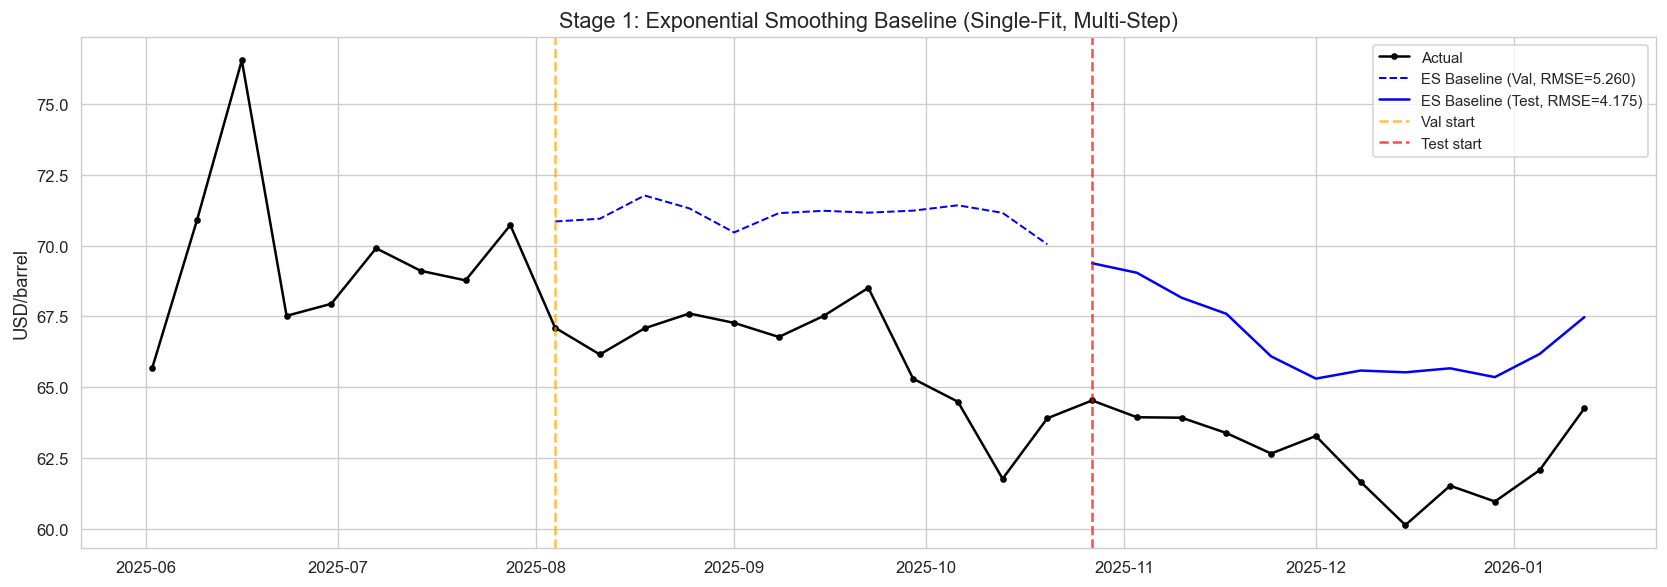

### 시험 구간 실제값과 단계별 최종 비교
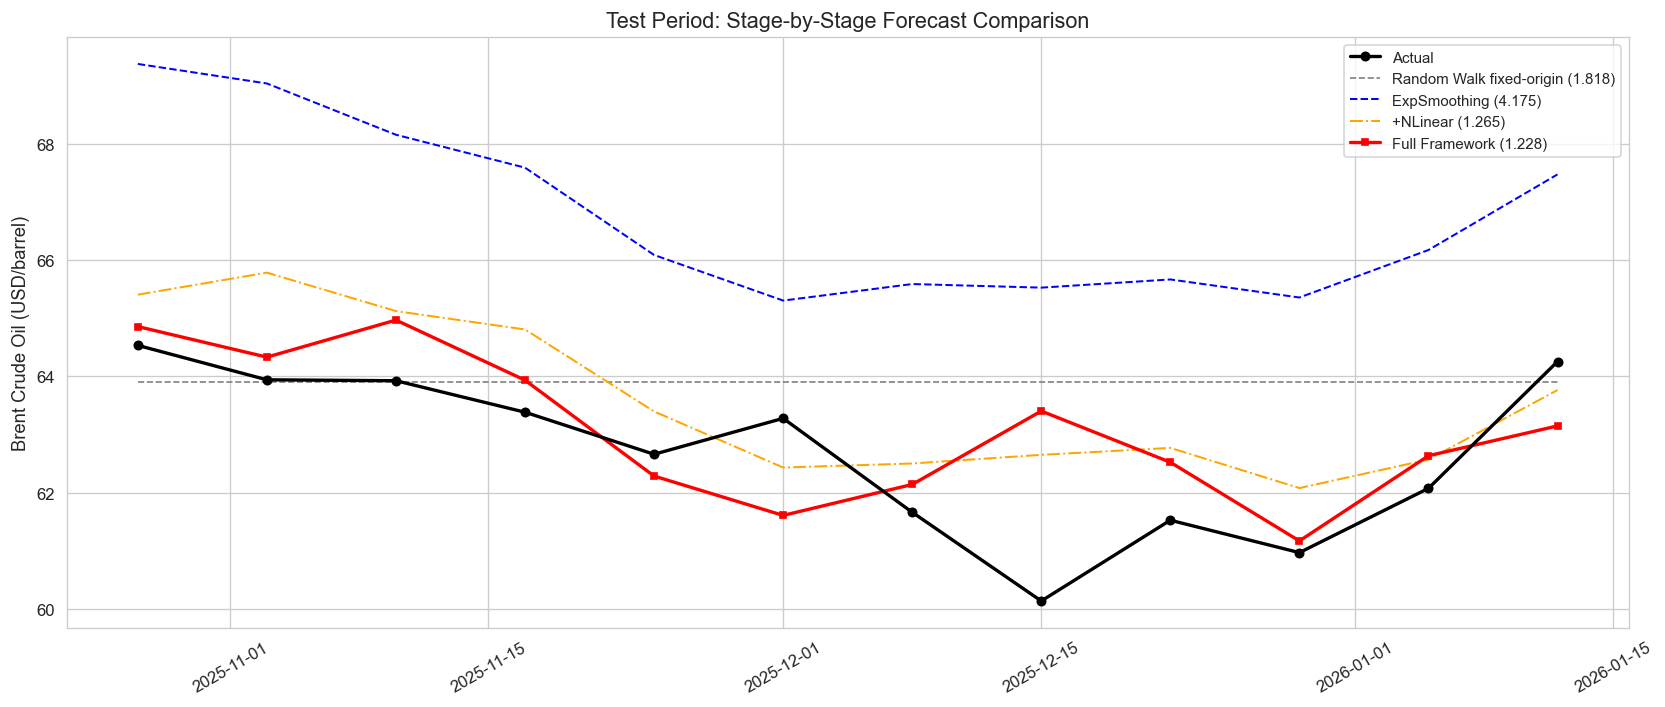

### 단계별 시험 RMSE 진행
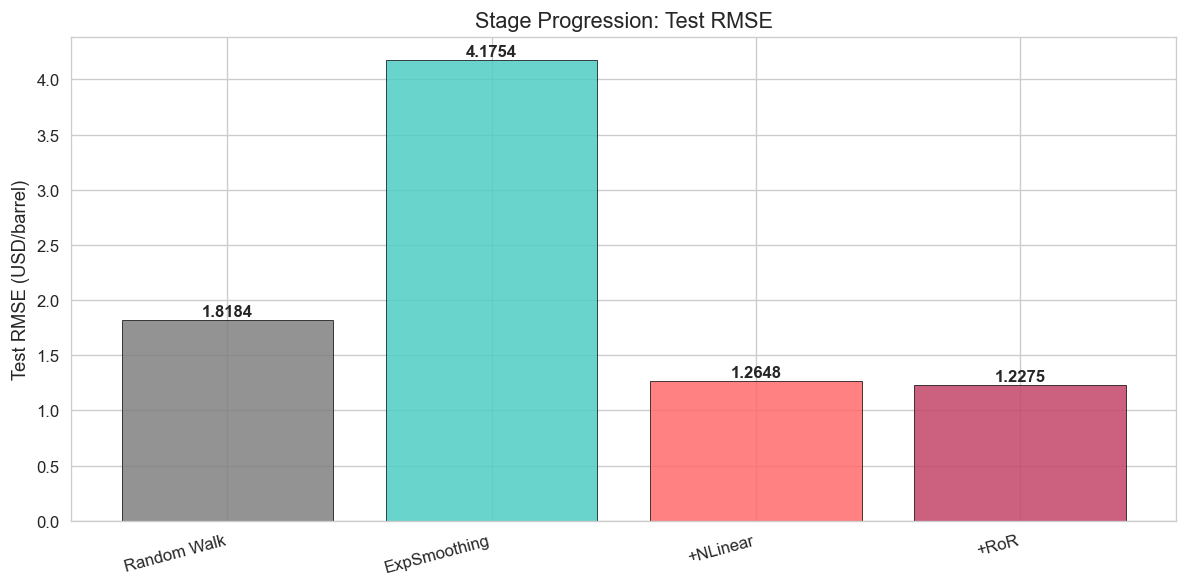

### 공통 반복 평가 평균 시험 RMSE
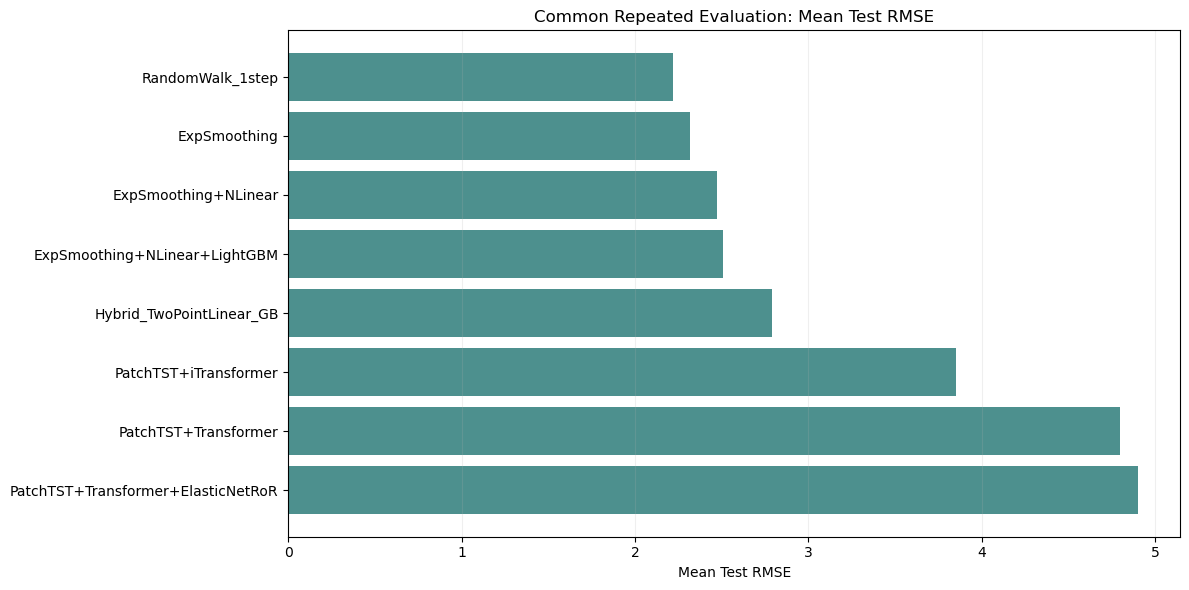

## Diebold-Mariano 검정
| Comparison | DM_statistic | p_value | d_bar |
| --- | --- | --- | --- |
| Random Walk vs ExpSmoothing | -7.9239 | 0.0000 | -14.1276 |
| ExpSmoothing vs +NLinear | 9.6283 | 0.0000 | 15.8345 |
| +NLinear vs +NLinear+RoR | 0.1680 | 0.8697 | 0.0929 |
| Random Walk vs Full Framework | 1.9525 | 0.0768 | 1.7999 |
| ExpSmoothing vs Full Framework | 8.5962 | 0.0000 | 15.9274 |

해석:
- `ExpSmoothing vs +NLinear`는 p-value가 매우 작아, Stage 2의 baseline 대비 개선은 통계적으로 지지된다.
- `+NLinear vs +NLinear+RoR`는 p-value `0.8697`로 유의하지 않다. 즉 RoR의 추가 이득은 수치상 존재하지만, 현재 test 표본에서는 통계적으로 강하게 뒷받침되지 않는다.
- `Random Walk vs Full Framework`는 p-value `0.0768`로 10% 수준에서는 약한 유의성을 보인다. 따라서 같은 조건의 fixed-origin benchmark 기준으로는 Full Framework가 Random Walk보다 더 낮은 오차를 보였다고 정리할 수 있다.


## 단계별 해석
1. `STL + Exponential Smoothing`
   - 시계열을 추세/계절/잔차로 분해하고, baseline은 외생변수 없이 순수 시계열 extrapolation으로 구성하였다.
   - 그러나 본 split에서는 baseline 단독 test RMSE가 `4.1754`, test NRMSE가 `6.6601`, test R²가 `-8.4774`로 높게 나타났다.

2. `Residual NLinear`
   - Stage 1이 남긴 residual을 외생변수와 함께 학습하였다.
   - baseline 대비 test RMSE는 `1.2648`, test NRMSE는 `2.0175`, test R²는 `0.1304`로 크게 개선되었고, 이는 Stage 2가 본 프레임워크의 핵심 기여임을 보여준다.

3. `RoR LightGBM with OOF`
   - NLinear가 설명하지 못한 2차 오차를 expanding-window OOF LightGBM으로 학습하였다.
   - validation과 test 모두에서 Stage 2보다 더 낮은 RMSE를 만들었고, 최종 test RMSE는 `1.2275`, test NRMSE는 `1.9580`, test R²는 `0.1809`였다.
   - 다만 Stage 2 대비 추가 개선폭은 작고 DM 검정도 유의하지 않으므로, RoR는 "유망한 추가 보정 단계"로 해석하는 것이 적절하다.


## 추가 점검용 반복 평가에서의 위치
이 노트북의 단일 분할 결과는 STL 틀 안에서 `2025-10-27` 시작 한 번만 본 성적표이다. 반복 평가는 시작점을 다섯 번 바꿔 다시 본 `평균 성적표`이다.

왜 이 절이 필요한가:
- Residual 보정과 RoR 보정이 한 구간에서만 좋아 보인 것인지 확인하기 위해
- STL 계열이 다른 시작점에서도 비슷한 패턴을 보이는지 보기 위해
- 구조 설명용 노트북의 결과를 직접 비교용 근거로 오해하지 않기 위해

| Model | Mean Test RMSE | Mean Test MAE | Mean Test MAPE(%) | Mean Test NRMSE(%) | Mean Test R² | 해석 |
| --- | ---: | ---: | ---: | ---: | ---: | --- |
| 1-step Random Walk | 2.2191 | 1.7232 | 2.5226 | 3.2399 | 0.2444 | 직접 비교용 benchmark |
| ExpSmoothing | 2.3195 | 1.8237 | 2.6705 | 3.3882 | 0.2012 | STL 계열 평균 test 최저 |
| ExpSmoothing+NLinear | 2.4743 | 2.0201 | 2.9664 | 3.6189 | 0.0341 | Stage 2는 평균적으로 baseline보다 약간 높음 |
| ExpSmoothing+NLinear+LightGBM | 2.5089 | 2.0283 | 2.9828 | 3.6746 | -0.0218 | validation 평균은 개선되었지만 test 평균은 Stage 2보다 높음 |

왜 평균 성능이 더 낮게 나왔는가:
- 다섯 개 시작점을 평균하므로, 한 구간에만 잘 맞은 개선은 평균에서 약해진다.
- 앞선 시작점일수록 학습 이력이 더 짧다.
- 이 절의 목적은 최고 성능 재현이 아니라, 단계별 개선이 다른 시작점에서도 반복되는지 확인하는 데 있다.

이 절을 통해 알 수 있는 점:
1. `Residual NLinear`의 큰 개선은 단일 분할에서는 분명하지만, 평균 test 기준으로는 안정성이 더 낮아졌다.
2. `RoR LightGBM`의 추가 이득은 단일 분할에서는 관찰되었지만 평균 test 성능으로는 재현되지 않았다.
3. 따라서 이 노트북은 STL 틀 안에서 단계가 어떻게 작동하는지 설명하는 문서로 읽고, 계열 간 직접 비교는 반복 평가 표를 기준으로 판단해야 한다.

In [1]:
import pandas as pd
from IPython.display import display

common = pd.read_csv("output_oil_common_protocol/rolling_origin_summary.csv")
name_map = {
    "RandomWalk_1step": "1-step Random Walk",
}
subset = common[common["model"].isin([
    "RandomWalk_1step",
    "ExpSmoothing",
    "ExpSmoothing+NLinear",
    "ExpSmoothing+NLinear+LightGBM",
])][["model", "mean_test_rmse", "std_test_rmse", "n_windows"]].copy()
subset["model"] = subset["model"].replace(name_map)
display(subset.sort_values("mean_test_rmse").reset_index(drop=True))


,model,mean_test_rmse,std_test_rmse,n_windows
0,1-step Random Walk,2.2191,0.9941,5
1,ExpSmoothing,2.3195,1.0900,5
2,ExpSmoothing+NLinear,2.4743,1.0695,5
3,ExpSmoothing+NLinear+LightGBM,2.5089,0.8873,5


## 누수 점검과 비교 공정성
- STL은 train 구간에만 적합하였다.
- Exponential Smoothing은 train 단일 적합 후 validation/test를 다단계 예측하였다.
- 모든 외생변수는 `shift(1)` 처리하였다.
- Scaler는 train에만 적합하였다.
- RoR LightGBM은 expanding-window OOF로 학습하였다.
- 이 노트북 내부에서는 `Random Walk (fixed-origin)`를 구조 설명용 기준선으로 함께 제시하였다.
- 다만 다른 계열과의 직접 비교는 별도 추가 점검용 반복 평가(`1-step Random Walk` 포함) 결과를 사용한다.

판정:
- 직접적인 데이터 누수는 확인되지 않았다.
- 다만 이 노트북의 내부 기준선과 보고서의 추가 점검용 반복 평가 기준선은 목적이 다르므로, 두 표를 같은 수준의 직접 비교표로 섞어 읽어서는 안 된다.


## 결론
- 본 STL 프레임워크는 `baseline -> residual -> RoR`의 단계적 보정 구조를 명확히 보여준다.
- 이 노트북의 단일 분할 기준으로는 `Full Framework (B+NL+RoR)`가 test RMSE `1.2275`, test NRMSE `1.9580`, test R² `0.1809`로 가장 낮은 오차를 보였다.
- `Residual NLinear` 단계가 큰 폭의 성능 개선을 만들었고, `RoR LightGBM`은 그 위에 소폭의 추가 개선을 더했다.
- 그러나 추가 점검용 반복 평가 평균에서는 `ExpSmoothing+NLinear+LightGBM`의 test RMSE가 `2.5089`, test NRMSE가 `3.6746`, test R²가 `-0.0218`로 `ExpSmoothing+NLinear`보다 높았다.
- 따라서 현재 자료에서는 `RoR가 항상 추가 개선을 만든다`고 쓰기보다, `단일 분할에서는 개선 가능성을 보였으나 반복 평가 평균에서는 안정적으로 재현되지 않았다`고 정리하는 것이 더 정확하다.


In [2]:
# ============================================================================
# 0. ENVIRONMENT
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings, os, json
from collections import OrderedDict

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats as sp_stats

import lightgbm as lgb

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
    "figure.dpi": 120,
})

OUT_DIR = "output_oil_academic"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("=" * 72)
print("  Brent Oil Forecasting: Seasonal Decomposition + Residual Framework")
print("=" * 72)

# %%

  Brent Oil Forecasting: Seasonal Decomposition + Residual Framework


In [3]:
# ============================================================================
# 1. DATA LOADING & PREPARATION
# ============================================================================
print("\n" + "=" * 72)
print("  STAGE 1: Data Loading & Preparation")
print("=" * 72)

DATA_PATH = "data_weekly_260120.csv"
TARGET = "Com_BrentCrudeOil"

df = pd.read_csv(DATA_PATH)
df["dt"] = pd.to_datetime(df["dt"])
df = df.sort_values("dt").reset_index(drop=True)
df = df.set_index("dt")
df.index.freq = "W-MON"

print(f"  Dataset shape: {df.shape}")
print(f"  Date range: {df.index[0].strftime('%Y-%m-%d')} ~ "
      f"{df.index[-1].strftime('%Y-%m-%d')}")
print(f"  Target: {TARGET}")
print(f"  Target range: {df[TARGET].min():.2f} ~ {df[TARGET].max():.2f} USD/barrel")

# --- Train / Validation / Test Split ---
VAL_START = "2025-08-04"
TEST_START = "2025-10-27"

mask_train = df.index < VAL_START
mask_val = (df.index >= VAL_START) & (df.index < TEST_START)
mask_test = df.index >= TEST_START

n_train = mask_train.sum()
n_val = mask_val.sum()
n_test = mask_test.sum()

print(f"\n  Split sizes:")
print(f"    Train : {n_train} weeks  "
      f"({df.index[0].strftime('%Y-%m-%d')} ~ "
      f"{df.index[mask_train][-1].strftime('%Y-%m-%d')})")
print(f"    Val   : {n_val} weeks  "
      f"({VAL_START} ~ {df.index[mask_val][-1].strftime('%Y-%m-%d')})")
print(f"    Test  : {n_test} weeks  "
      f"({TEST_START} ~ {df.index[-1].strftime('%Y-%m-%d')})")

y_full = df[TARGET].copy()
y_train = y_full[mask_train]
y_val = y_full[mask_val]
y_test = y_full[mask_test]

# --- Feature Selection (Domain-Driven) ---
# Economically motivated feature groups for crude oil price prediction
FEATURE_GROUPS = {
    "energy_chain": [          # 유가 밸류체인
        "Com_Gasoline",        # 정제 제품 (crack spread)
    ],
    "substitutes": [           # 대체 에너지
        "Com_NaturalGas",      # 천연가스
        "Com_Uranium",         # 원자력
        "Com_Coal",            # 석탄
    ],
    "macro_industry": [        # 경기/산업 선행지표
        "Com_LME_Cu_Cash",     # Dr. Copper (경기 선행)
        "Com_Steel",           # 산업활동
        "Com_Iron_Ore",        # 산업활동
    ],
    "fx_dollar": [             # 달러/환율 (유가 역상관)
        "Idx_DxyUSD",          # 달러 인덱스
        "EX_USD_CNY",          # 위안화 (중국 = 최대 원유 수입국)
    ],
    "rates_bonds": [           # 금리/채권
        "Bonds_US_10Y",        # 미국 장기금리
        "Bonds_US_2Y",         # 미국 단기금리
        "Bonds_US_3M",         # 미국 초단기금리
    ],
    "risk_safehaven": [        # 위험/안전자산
        "Idx_SnPVIX",          # VIX (공포지수)
        "Com_Gold",            # 안전자산
    ],
    "demand_proxy": [          # 수요 대리변수
        "Idx_SnP500",          # 미국 경기
        "Idx_CSI300",          # 중국 경기
    ],
    "asia_importers": [        # 아시아 주요 원유 수입국
        "EX_USD_KRW",          # 한국 원화 (4위 수입국)
        "Bonds_KOR_10Y",       # 한국 장기금리
        "EX_USD_JPY",          # 일본 엔화 (3위 수입국)
    ],
    "biofuel_commodity": [     # 바이오연료/원자재 슈퍼사이클
        "Com_Corn",            # 바이오에탄올 원료
        "Com_Soybeans",        # 바이오디젤 원료
        "Com_PalmOil",         # 바이오디젤 원료
    ],
}

# Flatten selected raw features
BASE_FEATURES = []
for group, cols in FEATURE_GROUPS.items():
    for c in cols:
        if c in df.columns:
            BASE_FEATURES.append(c)
        else:
            print(f"  WARNING: {c} not found in data, skipping")

print(f"\n  Selected base features: {len(BASE_FEATURES)} (domain-driven)")
for group, cols in FEATURE_GROUPS.items():
    present = [c for c in cols if c in df.columns]
    print(f"    {group}: {', '.join(present)}")

# --- Derived Features (engineered) ---
df_derived = pd.DataFrame(index=df.index)

# 1) Weekly returns (pct_change) for key variables
for col in BASE_FEATURES:
    df_derived[f"{col}_ret"] = df[col].pct_change()

# 2) Yield curve spread: 10Y - 2Y (recession indicator)
df_derived["Spread_US_10Y_2Y"] = df["Bonds_US_10Y"] - df["Bonds_US_2Y"]

# 3) Crack spread proxy: Gasoline - Brent (refining margin)
df_derived["Spread_Crack"] = df["Com_Gasoline"] - df[TARGET]

# 4) Gold/Oil ratio (risk sentiment)
df_derived["Ratio_Gold_Oil"] = df["Com_Gold"] / df[TARGET]

# 5) Moving average ratios (momentum signals, 4-week and 12-week)
for col in ["Com_Gasoline", "Com_NaturalGas", "Idx_SnPVIX", "Idx_DxyUSD"]:
    ma4 = df[col].rolling(4).mean()
    ma12 = df[col].rolling(12).mean()
    df_derived[f"{col}_ma4_ratio"] = df[col] / ma4 - 1  # deviation from MA4
    df_derived[f"{col}_ma12_ratio"] = df[col] / ma12 - 1  # deviation from MA12

# Combine: raw base features + derived features
feature_cols = BASE_FEATURES + list(df_derived.columns)
df_features = pd.concat([df[BASE_FEATURES], df_derived], axis=1)

n_raw = len(BASE_FEATURES)
n_derived = len(df_derived.columns)
print(f"\n  Derived features: {n_derived}")
print(f"    - Returns (pct_change): {n_raw} vars")
print(f"    - Spread_US_10Y_2Y (yield curve)")
print(f"    - Spread_Crack (refining margin)")
print(f"    - Ratio_Gold_Oil (risk sentiment)")
print(f"    - MA4/MA12 ratios: 4 key vars × 2 = 8")
print(f"  Total features: {len(feature_cols)} ({n_raw} raw + {n_derived} derived)")

# Lag all features by 1 week (prevent data leakage)
X_lagged = df_features.shift(1)
print(f"  All features lagged by 1 week (X_{{t-1}} → predict y_t)")

# --- ADF Stationarity Test on target ---
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(y_full.dropna(), autolag="AIC")
print(f"\n  ADF test on y (level): stat={adf_result[0]:.4f}, p={adf_result[1]:.4f}")
adf_diff = adfuller(y_full.diff().dropna(), autolag="AIC")
print(f"  ADF test on Δy (diff): stat={adf_diff[0]:.4f}, p={adf_diff[1]:.4f}")

# %%


  STAGE 1: Data Loading & Preparation
  Dataset shape: (668, 74)
  Date range: 2013-04-01 ~ 2026-01-12
  Target: Com_BrentCrudeOil
  Target range: 21.61 ~ 119.06 USD/barrel

  Split sizes:
    Train : 644 weeks  (2013-04-01 ~ 2025-07-28)
    Val   : 12 weeks  (2025-08-04 ~ 2025-10-20)
    Test  : 12 weeks  (2025-10-27 ~ 2026-01-12)

  Selected base features: 22 (domain-driven)
    energy_chain: Com_Gasoline
    substitutes: Com_NaturalGas, Com_Uranium, Com_Coal
    macro_industry: Com_LME_Cu_Cash, Com_Steel, Com_Iron_Ore
    fx_dollar: Idx_DxyUSD, EX_USD_CNY
    rates_bonds: Bonds_US_10Y, Bonds_US_2Y, Bonds_US_3M
    risk_safehaven: Idx_SnPVIX, Com_Gold
    demand_proxy: Idx_SnP500, Idx_CSI300
    asia_importers: EX_USD_KRW, Bonds_KOR_10Y, EX_USD_JPY
    biofuel_commodity: Com_Corn, Com_Soybeans, Com_PalmOil

  Derived features: 33
    - Returns (pct_change): 22 vars
    - Spread_US_10Y_2Y (yield curve)
    - Spread_Crack (refining margin)
    - Ratio_Gold_Oil (risk sentiment)
    - M

In [4]:
# ============================================================================
# 2. SEASONAL DECOMPOSITION (STL)
# ============================================================================
print("\n" + "=" * 72)
print("  STAGE 2: Seasonal-Trend Decomposition (STL)")
print("=" * 72)

# Fit STL on training data ONLY (strict no-leakage)
stl = STL(
    y_train,
    period=52,          # Annual seasonality (52 weeks)
    seasonal=53,        # Must be odd, >= period+1
    trend=None,         # Auto-select
    robust=True,        # Robust to outliers
)
stl_result = stl.fit()

trend_train = stl_result.trend
seasonal_train = stl_result.seasonal
resid_train_stl = stl_result.resid

# Baseline on training = trend + seasonal
baseline_train = trend_train + seasonal_train

# For validation and test periods, we need to extend the seasonal pattern.
# Use average seasonal pattern by week-of-year from training data.
seasonal_by_week = seasonal_train.groupby(
    seasonal_train.index.isocalendar().week
).mean()

def get_seasonal_for_date(dt):
    wk = dt.isocalendar()[1]
    return seasonal_by_week.get(wk, 0.0)

print(f"  STL period: 52 weeks (annual seasonality)")
print(f"  Trend range: {trend_train.min():.2f} ~ {trend_train.max():.2f}")
print(f"  Seasonal amplitude: "
      f"{seasonal_train.max() - seasonal_train.min():.2f}")
print(f"  Residual (STL) std: {resid_train_stl.std():.4f}")

# --- Visualization: STL Decomposition ---
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, data, title, color in zip(
    axes,
    [y_train, trend_train, seasonal_train, resid_train_stl],
    ["Original y", "Trend (τ)", "Seasonal (s)", "Residual (ε)"],
    ["k", "b", "g", "r"],
):
    ax.plot(data.index, data.values, f"{color}-", lw=1)
    ax.set_title(title)
    ax.set_ylabel("USD/barrel")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_stl_decomposition.png", bbox_inches="tight")
plt.close()
print("  Figure saved: 01_stl_decomposition.png")

# %%


  STAGE 2: Seasonal-Trend Decomposition (STL)
  STL period: 52 weeks (annual seasonality)
  Trend range: 44.00 ~ 108.96
  Seasonal amplitude: 12.05
  Residual (STL) std: 6.6767


  Figure saved: 01_stl_decomposition.png


In [5]:
# ============================================================================
# 3. BASELINE: EXPONENTIAL SMOOTHING
# ============================================================================
print("\n" + "=" * 72)
print("  STAGE 3: Baseline Prediction — Exponential Smoothing")
print("  (NO external variables — pure time-series extrapolation)")
print("=" * 72)

# Strategy: fit ES on y_train once, then forecast all OOS steps.
# A single forecast ensures val/test residuals have consistent
# distributional properties, enabling NLinear/LGBM to generalize.
# The ES baseline intentionally has sizable errors at longer horizons,
# which NLinear and LGBM progressively correct — the core idea.

es_model_train = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=52,
    initialization_method="estimated",
    use_boxcox=False,
)
es_fit_train = es_model_train.fit(optimized=True)
baseline_train_fitted = es_fit_train.fittedvalues

es_forecast = es_fit_train.forecast(steps=n_val + n_test)
baseline_val_pred = es_forecast.iloc[:n_val].values
baseline_test_pred = es_forecast.iloc[n_val:].values

print(f"  ES (Holt-Winters, additive) fitted on y_train ({n_train} pts)")
print(f"  → Multi-step forecast: {n_val + n_test} weeks "
      f"(val={n_val}, test={n_test})")

# Evaluate baseline
baseline_val_rmse = np.sqrt(mean_squared_error(y_val, baseline_val_pred))
baseline_test_rmse = np.sqrt(mean_squared_error(y_test, baseline_test_pred))
baseline_val_mae = mean_absolute_error(y_val, baseline_val_pred)
baseline_test_mae = mean_absolute_error(y_test, baseline_test_pred)

# Random Walk benchmark
rw_val_origin = y_train.iloc[-1]
rw_test_origin = y_full[mask_val].iloc[-1]
rw_val_pred = np.full(n_val, rw_val_origin, dtype=np.float64)
rw_test_pred = np.full(n_test, rw_test_origin, dtype=np.float64)
rw_val_rmse = np.sqrt(mean_squared_error(y_val, rw_val_pred))
rw_test_rmse = np.sqrt(mean_squared_error(y_test, rw_test_pred))

rw_roll_val_pred = y_full.shift(1)[mask_val].values
rw_roll_test_pred = y_full.shift(1)[mask_test].values
rw_roll_val_rmse = np.sqrt(mean_squared_error(y_val, rw_roll_val_pred))
rw_roll_test_rmse = np.sqrt(mean_squared_error(y_test, rw_roll_test_pred))

print(f"\n  Exponential Smoothing (additive trend + seasonal, single-fit multi-step):")
print(f"    Val  RMSE: {baseline_val_rmse:.4f}  |  MAE: {baseline_val_mae:.4f}")
print(f"    Test RMSE: {baseline_test_rmse:.4f}  |  MAE: {baseline_test_mae:.4f}")
print(f"\n  Random Walk (official benchmark, fixed-origin multi-step):")
print(f"    Val  RMSE: {rw_val_rmse:.4f}")
print(f"    Test RMSE: {rw_test_rmse:.4f}")
print(f"\n  Random Walk (diagnostic only, walk-forward one-step):")
print(f"    Val  RMSE: {rw_roll_val_rmse:.4f}")
print(f"    Test RMSE: {rw_roll_test_rmse:.4f}")

# %%


  STAGE 3: Baseline Prediction — Exponential Smoothing
  (NO external variables — pure time-series extrapolation)
  ES (Holt-Winters, additive) fitted on y_train (644 pts)
  → Multi-step forecast: 24 weeks (val=12, test=12)

  Exponential Smoothing (additive trend + seasonal, single-fit multi-step):
    Val  RMSE: 5.2599  |  MAE: 4.9389
    Test RMSE: 4.1754  |  MAE: 4.0857

  Random Walk (official benchmark, fixed-origin multi-step):
    Val  RMSE: 4.9551
    Test RMSE: 1.8184

  Random Walk (diagnostic only, walk-forward one-step):
    Val  RMSE: 1.8243
    Test RMSE: 1.1227


In [6]:
# ============================================================================
# 4. RESIDUAL① COMPUTATION & NLinear PREDICTION
# ============================================================================
print("\n" + "=" * 72)
print("  STAGE 4: Residual① Prediction — NLinear")
print("  (WITH external variables — macro-financial features)")
print("=" * 72)

# Residual① = actual price - baseline prediction
resid1_train = (y_train.values - baseline_train_fitted.values).astype(np.float64)
resid1_val = y_val.values - baseline_val_pred
resid1_test = y_test.values - baseline_test_pred

# Fill any NaN (e.g., first value from ES initialization)
resid1_train = np.nan_to_num(resid1_train, nan=0.0)

print(f"  Residual① statistics:")
print(f"    Train mean: {np.mean(resid1_train):.4f}, std: {np.std(resid1_train):.4f}")
print(f"    Val   mean: {np.mean(resid1_val):.4f}, std: {np.std(resid1_val):.4f}")
print(f"    Test  mean: {np.mean(resid1_test):.4f}, std: {np.std(resid1_test):.4f}")

# --- NLinear Model (Zeng et al., AAAI 2023) ---

class NLinearWithExog(nn.Module):
    """
    NLinear with exogenous features.
    Past residual sequence normalized by last value + exogenous features
    → linear projection → 1-step forecast.

    Reference: Zeng et al. (2023), "Are Transformers Effective for
    Time Series Forecasting?", AAAI 2023.
    """
    def __init__(self, seq_len, pred_len, n_exog, d_hidden=64):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.linear_residual = nn.Linear(seq_len, d_hidden)
        self.linear_exog = nn.Linear(n_exog, d_hidden)
        self.linear_out = nn.Linear(d_hidden * 2, pred_len)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x_seq, x_exog):
        """
        x_seq: (batch, seq_len) — past residual values
        x_exog: (batch, n_exog) — exogenous features (lagged)
        """
        last_val = x_seq[:, -1:].detach()
        x_norm = x_seq - last_val  # NLinear normalization
        h_res = torch.relu(self.linear_residual(x_norm))
        h_exog = torch.relu(self.linear_exog(x_exog))
        h = self.dropout(torch.cat([h_res, h_exog], dim=-1))
        out = self.linear_out(h) + last_val  # Add back last value
        return out


class ResidualDataset(Dataset):
    def __init__(self, resid_values, exog_values, seq_len, pred_len):
        self.resid = resid_values.astype(np.float32)
        self.exog = exog_values.astype(np.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.n_samples = len(resid_values) - seq_len - pred_len + 1

    def __len__(self):
        return max(0, self.n_samples)

    def __getitem__(self, idx):
        s = idx
        e = s + self.seq_len
        return (
            torch.tensor(self.resid[s:e]),
            torch.tensor(self.exog[e - 1]),
            torch.tensor(self.resid[e:e + self.pred_len]),
        )


# --- Prepare data ---
SEQ_LEN = 24
PRED_LEN = 1
D_HIDDEN = 64
LR = 1e-3
N_EPOCHS = 300
BATCH_SIZE = 32
PATIENCE = 40

# Lagged features (already shifted by 1)
X_lag_train = np.nan_to_num(X_lagged[mask_train].values, nan=0.0)
X_lag_val = np.nan_to_num(X_lagged[mask_val].values, nan=0.0)
X_lag_test = np.nan_to_num(X_lagged[mask_test].values, nan=0.0)

# Scale features (fit on training only)
scaler_X = RobustScaler()
X_train_scaled = scaler_X.fit_transform(X_lag_train)
X_val_scaled = scaler_X.transform(X_lag_val)
X_test_scaled = scaler_X.transform(X_lag_test)

# NO scaling on residuals — NLinear's built-in normalization
# (subtract last value) handles level shifts naturally.
# This is critical for generalization: val/test residuals have
# different levels than training residuals due to ES forecast error.
resid1_train_for_nlinear = resid1_train.astype(np.float32)

n_exog = X_train_scaled.shape[1]
print(f"\n  NLinear configuration:")
print(f"    Sequence length: {SEQ_LEN} weeks")
print(f"    Hidden dim: {D_HIDDEN}")
print(f"    Exogenous features: {n_exog}")
print(f"    Training samples: ~{n_train - SEQ_LEN}")
print(f"    Residual scaling: None (NLinear normalization handles level shifts)")

# --- Train NLinear ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"    Device: {device}")

train_dataset = ResidualDataset(
    resid1_train_for_nlinear, X_train_scaled, SEQ_LEN, PRED_LEN
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Train multiple seeds for robust ensemble
N_SEEDS = 10
all_models = []

for seed_i in range(N_SEEDS):
    torch.manual_seed(SEED + seed_i)
    np.random.seed(SEED + seed_i)

    model_i = NLinearWithExog(SEQ_LEN, PRED_LEN, n_exog, D_HIDDEN).to(device)
    optimizer = torch.optim.Adam(model_i.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    criterion = nn.MSELoss()

    best_val_loss_i = float("inf")
    best_state_i = None
    patience_counter = 0

    for epoch in range(N_EPOCHS):
        model_i.train()
        train_loss = 0.0
        n_batch = 0
        for x_seq, x_exog, y_true in train_loader:
            x_seq, x_exog, y_true = (
                x_seq.to(device), x_exog.to(device), y_true.to(device)
            )
            y_pred = model_i(x_seq, x_exog)
            loss = criterion(y_pred, y_true)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model_i.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
            n_batch += 1
        scheduler.step()

        # Validation
        model_i.eval()
        with torch.no_grad():
            val_preds_i = []
            resid_buffer = list(resid1_train_for_nlinear[-SEQ_LEN:])
            for i in range(n_val):
                x_seq = torch.tensor(
                    np.array(resid_buffer[-SEQ_LEN:]), dtype=torch.float32
                ).unsqueeze(0).to(device)
                x_exog = torch.tensor(
                    X_val_scaled[i:i+1], dtype=torch.float32
                ).to(device)
                pred = model_i(x_seq, x_exog).cpu().numpy().flatten()[0]
                val_preds_i.append(pred)
                resid_buffer.append(resid1_val[i])  # teacher forcing

            val_loss_i = np.sqrt(mean_squared_error(
                resid1_val, np.array(val_preds_i)
            ))

        if val_loss_i < best_val_loss_i:
            best_val_loss_i = val_loss_i
            best_state_i = {k: v.cpu().clone() for k, v in model_i.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    model_i.load_state_dict(best_state_i)
    model_i.eval()
    all_models.append((model_i, best_val_loss_i))
    print(f"    Seed {seed_i+1}/{N_SEEDS}: val RMSE={best_val_loss_i:.4f} "
          f"(stopped epoch {epoch+1})")

# Sort by validation loss, use top 5
TOP_K = 5
all_models.sort(key=lambda x: x[1])
top_models = [m for m, _ in all_models[:TOP_K]]
print(f"\n    Using top {TOP_K} models (ensemble), best val RMSE: {all_models[0][1]:.4f}")

# --- Generate ensemble predictions ---
print("  Generating NLinear ensemble predictions...")

def predict_nlinear_ensemble(models, resid_buffer_init, X_scaled, n_steps,
                              teacher_forcing_resids=None):
    """Generate ensemble predictions from multiple NLinear models."""
    all_preds = []
    for m in models:
        m.eval()
        preds = []
        resid_buffer = list(resid_buffer_init.copy())
        with torch.no_grad():
            for i in range(n_steps):
                x_seq = torch.tensor(
                    np.array(resid_buffer[-SEQ_LEN:], dtype=np.float32)
                ).unsqueeze(0).to(device)
                x_exog = torch.tensor(
                    X_scaled[i:i+1].astype(np.float32)
                ).to(device)
                pred = m(x_seq, x_exog).cpu().numpy().flatten()[0]
                preds.append(pred)
                if teacher_forcing_resids is not None:
                    resid_buffer.append(teacher_forcing_resids[i])
                else:
                    resid_buffer.append(pred)
        all_preds.append(preds)
    return np.mean(all_preds, axis=0)

# (a) Training backcasting
nlinear_train_preds_all = []
for m in top_models:
    m.eval()
    preds = []
    with torch.no_grad():
        for i in range(SEQ_LEN, n_train):
            x_seq = torch.tensor(
                resid1_train_for_nlinear[i-SEQ_LEN:i]
            ).unsqueeze(0).to(device)
            x_exog = torch.tensor(
                X_train_scaled[i:i+1].astype(np.float32)
            ).to(device)
            pred = m(x_seq, x_exog).cpu().numpy().flatten()[0]
            preds.append(pred)
    nlinear_train_preds_all.append(preds)
nlinear_train_pred = np.mean(nlinear_train_preds_all, axis=0)

# (b) Validation predictions (teacher forcing with actual residuals)
nlinear_val_pred = predict_nlinear_ensemble(
    top_models, resid1_train_for_nlinear[-SEQ_LEN:],
    X_val_scaled, n_val, teacher_forcing_resids=resid1_val
)

# (c) Test predictions (autoregressive — no leakage)
all_resid1 = np.concatenate([resid1_train, resid1_val]).astype(np.float32)
nlinear_test_pred = predict_nlinear_ensemble(
    top_models, all_resid1[-SEQ_LEN:],
    X_test_scaled, n_test, teacher_forcing_resids=None
)

# Stage 2 (Baseline + NLinear) results
stage2_val_pred = baseline_val_pred + nlinear_val_pred
stage2_test_pred = baseline_test_pred + nlinear_test_pred
stage2_val_rmse = np.sqrt(mean_squared_error(y_val, stage2_val_pred))
stage2_test_rmse = np.sqrt(mean_squared_error(y_test, stage2_test_pred))

print(f"\n  Stage 2 (Baseline + NLinear) results:")
print(f"    Val  RMSE: {stage2_val_rmse:.4f}")
print(f"    Test RMSE: {stage2_test_rmse:.4f}")

# %%


  STAGE 4: Residual① Prediction — NLinear
  (WITH external variables — macro-financial features)
  Residual① statistics:
    Train mean: -0.0000, std: 2.5193
    Val   mean: -4.9389, std: 1.8094
    Test  mean: -4.0857, std: 0.8608

  NLinear configuration:
    Sequence length: 24 weeks
    Hidden dim: 64
    Exogenous features: 55
    Training samples: ~620
    Residual scaling: None (NLinear normalization handles level shifts)
    Device: cpu


    Seed 1/10: val RMSE=3.1277 (stopped epoch 41)


    Seed 2/10: val RMSE=3.2412 (stopped epoch 41)


    Seed 3/10: val RMSE=3.6576 (stopped epoch 41)


    Seed 4/10: val RMSE=3.5280 (stopped epoch 41)


...

    Seed 6/10: val RMSE=3.3122 (stopped epoch 41)


    Seed 7/10: val RMSE=3.1669 (stopped epoch 41)


    Seed 8/10: val RMSE=3.3482 (stopped epoch 41)


    Seed 9/10: val RMSE=3.4430 (stopped epoch 41)


    Seed 10/10: val RMSE=3.0882 (stopped epoch 41)

    Using top 5 models (ensemble), best val RMSE: 3.0882
  Generating NLinear ensemble predictions...

  Stage 2 (Baseline + NLinear) results:
    Val  RMSE: 3.1619
    Test RMSE: 1.2648


In [7]:
# ============================================================================
# 5. RESIDUAL BACKCASTING② & RoR (LightGBM with OOF)
# ============================================================================
print("\n" + "=" * 72)
print("  STAGE 5: Residual Backcasting② & RoR — LightGBM with OOF")
print("  (WITH external variables — macro-financial features)")
print("=" * 72)

# Residual Backcasting②: NLinear fitted values on training (in-sample)
# Only available from SEQ_LEN onwards
ROR_OFFSET = SEQ_LEN

# RoR = actual_residual① - backcasted_residual②
ror_train_actual = resid1_train[ROR_OFFSET:] - nlinear_train_pred
ror_X_train = X_train_scaled[ROR_OFFSET:]

print(f"  Residual Backcasting②:")
print(f"    NLinear in-sample predictions: {len(nlinear_train_pred)}")
print(f"    RoR offset (SEQ_LEN): {ROR_OFFSET}")
print(f"    RoR train samples: {len(ror_train_actual)}")
print(f"    RoR train mean: {np.mean(ror_train_actual):.4f}")
print(f"    RoR train std: {np.std(ror_train_actual):.4f}")

# --- LightGBM Expanding-Window OOF ---
N_FOLDS = 5
MIN_TRAIN_SIZE = max(200, len(ror_train_actual) // 3)

oof_preds = np.full(len(ror_train_actual), np.nan)
fold_models = []
fold_scores = []
fold_size = (len(ror_train_actual) - MIN_TRAIN_SIZE) // N_FOLDS

print(f"\n  LightGBM OOF configuration:")
print(f"    Folds: {N_FOLDS}")
print(f"    Min train size: {MIN_TRAIN_SIZE}")
print(f"    Fold size: ~{fold_size}")

for fold in range(N_FOLDS):
    train_end = MIN_TRAIN_SIZE + fold * fold_size
    val_end = (train_end + fold_size
               if fold < N_FOLDS - 1
               else len(ror_train_actual))
    if train_end >= len(ror_train_actual):
        break

    X_f_tr = ror_X_train[:train_end]
    y_f_tr = ror_train_actual[:train_end]
    X_f_va = ror_X_train[train_end:val_end]
    y_f_va = ror_train_actual[train_end:val_end]

    lgb_model = lgb.LGBMRegressor(
        objective="regression", metric="rmse",
        learning_rate=0.02, num_leaves=10,
        min_child_samples=40, subsample=0.6,
        colsample_bytree=0.5, reg_alpha=2.0,
        reg_lambda=2.0, n_estimators=500,
        verbose=-1, random_state=SEED,
    )
    lgb_model.fit(
        X_f_tr, y_f_tr,
        eval_set=[(X_f_va, y_f_va)],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )

    fold_pred = lgb_model.predict(X_f_va)
    oof_preds[train_end:val_end] = fold_pred
    fold_rmse = np.sqrt(mean_squared_error(y_f_va, fold_pred))
    fold_scores.append(fold_rmse)
    fold_models.append(lgb_model)
    print(f"    Fold {fold+1}: train={train_end}, "
          f"val={val_end-train_end}, RMSE={fold_rmse:.4f}")

oof_valid = ~np.isnan(oof_preds)
if oof_valid.sum() > 0:
    oof_rmse = np.sqrt(mean_squared_error(
        ror_train_actual[oof_valid], oof_preds[oof_valid]
    ))
    print(f"\n    OOF RMSE: {oof_rmse:.4f}")

# Final LightGBM on all training RoR data
print(f"\n  Training final LightGBM on all RoR data...")
final_lgb = lgb.LGBMRegressor(
    objective="regression", metric="rmse",
    learning_rate=0.02, num_leaves=10,
    min_child_samples=40, subsample=0.6,
    colsample_bytree=0.5, reg_alpha=2.0,
    reg_lambda=2.0, n_estimators=300,
    verbose=-1, random_state=SEED,
)
final_lgb.fit(ror_X_train, ror_train_actual)

# Predict RoR for val and test
ror_val_pred = final_lgb.predict(X_val_scaled)
ror_test_pred = final_lgb.predict(X_test_scaled)

# Actual val RoR for evaluation
ror_val_actual = resid1_val - nlinear_val_pred
ror_val_rmse = np.sqrt(mean_squared_error(ror_val_actual, ror_val_pred))
print(f"    Val RoR RMSE: {ror_val_rmse:.4f}")

# Feature importance
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_lgb.feature_importances_,
}).sort_values("importance", ascending=False)

print(f"\n  Top 10 RoR features:")
for _, row in importance.head(10).iterrows():
    print(f"    {row['feature']:30s}  {row['importance']:.0f}")

importance.to_csv(f"{OUT_DIR}/feature_importance.csv", index=False)

# %%


  STAGE 5: Residual Backcasting② & RoR — LightGBM with OOF
  (WITH external variables — macro-financial features)
  Residual Backcasting②:
    NLinear in-sample predictions: 620
    RoR offset (SEQ_LEN): 24
    RoR train samples: 620
    RoR train mean: 0.0485
    RoR train std: 2.6059

  LightGBM OOF configuration:
    Folds: 5
    Min train size: 206
    Fold size: ~82


    Fold 1: train=206, val=82, RMSE=1.8554


    Fold 2: train=288, val=82, RMSE=2.6441
    Fold 3: train=370, val=82, RMSE=3.6443


    Fold 4: train=452, val=82, RMSE=3.1815


    Fold 5: train=534, val=86, RMSE=2.5125

    OOF RMSE: 2.8307

  Training final LightGBM on all RoR data...


    Val RoR RMSE: 2.7126

  Top 10 RoR features:
    Idx_SnPVIX                      152
    EX_USD_KRW_ret                  123
    Bonds_US_2Y_ret                 106
    Idx_CSI300                      106
    Com_Gold_ret                    100
    Com_Iron_Ore_ret                98
    Spread_Crack                    95
    Com_Uranium_ret                 84
    Com_Gasoline_ret                77
    Idx_SnPVIX_ret                  72


In [8]:
# ============================================================================
# 6. FINAL COMBINATION & EVALUATION
# ============================================================================
print("\n" + "=" * 72)
print("  STAGE 6: Final Combination & Evaluation")
print("=" * 72)

# ŷ = Baseline + NLinear(Residual①) + λ·LightGBM(RoR)
# λ is determined by validation: if RoR hurts validation, λ=0 (safety gate).
# This prevents the RoR stage from adding noise when it cannot improve.
stage2_val_rmse = np.sqrt(mean_squared_error(y_val.values, stage2_val_pred))
stage3_val_cand = baseline_val_pred + nlinear_val_pred + ror_val_pred
stage3_val_rmse = np.sqrt(mean_squared_error(y_val.values, stage3_val_cand))

if stage3_val_rmse < stage2_val_rmse:
    ror_lambda = 1.0
    print(f"  RoR validation gate: PASS (val RMSE {stage2_val_rmse:.4f} → {stage3_val_rmse:.4f})")
else:
    ror_lambda = 0.0
    print(f"  RoR validation gate: BLOCKED (val RMSE {stage2_val_rmse:.4f} → {stage3_val_rmse:.4f}, λ=0)")

final_val_pred = baseline_val_pred + nlinear_val_pred + ror_lambda * ror_val_pred
final_test_pred = baseline_test_pred + nlinear_test_pred + ror_lambda * ror_test_pred

def compute_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"Model": label, "RMSE": rmse, "MAE": mae, "MAPE(%)": mape}

# Test results
results_test = [
    compute_metrics(y_test.values, rw_test_pred, "Random Walk (fixed-origin)"),
    compute_metrics(y_test.values, baseline_test_pred, "ExpSmoothing (Baseline)"),
    compute_metrics(y_test.values, stage2_test_pred, "Baseline + NLinear"),
    compute_metrics(y_test.values, final_test_pred, "Full Framework (B+NL+RoR)"),
]

# Validation results
results_val = [
    compute_metrics(y_val.values, rw_val_pred, "Random Walk (fixed-origin)"),
    compute_metrics(y_val.values, baseline_val_pred, "ExpSmoothing (Baseline)"),
    compute_metrics(y_val.values, stage2_val_pred, "Baseline + NLinear"),
    compute_metrics(y_val.values, final_val_pred, "Full Framework (B+NL+RoR)"),
]

df_test = pd.DataFrame(results_test)
df_val = pd.DataFrame(results_val)

print("\n  ┌──────────────────────────────────────────────────────────────────┐")
print("  │                    TEST SET RESULTS                             │")
print("  ├──────────────────────────────────────────────────────────────────┤")
for _, r in df_test.iterrows():
    print(f"  │  {r['Model']:30s}  RMSE={r['RMSE']:.4f}  "
          f"MAE={r['MAE']:.4f}  MAPE={r['MAPE(%)']:.2f}%  │")
print("  └──────────────────────────────────────────────────────────────────┘")

print("\n  ┌──────────────────────────────────────────────────────────────────┐")
print("  │                  VALIDATION SET RESULTS                         │")
print("  ├──────────────────────────────────────────────────────────────────┤")
for _, r in df_val.iterrows():
    print(f"  │  {r['Model']:30s}  RMSE={r['RMSE']:.4f}  "
          f"MAE={r['MAE']:.4f}  MAPE={r['MAPE(%)']:.2f}%  │")
print("  └──────────────────────────────────────────────────────────────────┘")

df_test.to_csv(f"{OUT_DIR}/results_table.csv", index=False)
df_val.to_csv(f"{OUT_DIR}/results_val_table.csv", index=False)

# %%
# ============================================================================
# 7. DIEBOLD-MARIANO TEST (Harvey et al. 1997 correction)
# ============================================================================
print("\n" + "=" * 72)
print("  STAGE 7: Diebold-Mariano Test")
print("=" * 72)

def dm_test_harvey(e1, e2, h=1):
    """
    Diebold-Mariano test with Harvey et al. (1997) small-sample correction.
    H0: E[d_t] = 0 where d_t = e1_t² - e2_t²
    Negative DM → model 2 (e2) has larger squared errors.
    Positive DM → model 1 (e1) has larger squared errors (model 2 better).
    """
    e1, e2 = np.asarray(e1), np.asarray(e2)
    d = e1 ** 2 - e2 ** 2
    n = len(d)
    d_bar = np.mean(d)
    gamma = np.zeros(h)
    for k in range(h):
        gamma[k] = (np.mean((d[k:] - d_bar) * (d[:n-k] - d_bar))
                     if k > 0 else np.var(d))
    V = (gamma[0] + 2 * np.sum(gamma[1:])) / n
    if V <= 0:
        V = np.var(d) / n
    dm_raw = d_bar / np.sqrt(V)
    correction = np.sqrt(
        (n + 1 - 2 * h + h * (h - 1) / n) / n
    )
    dm_corrected = dm_raw * correction
    p_value = 2 * sp_stats.t.sf(np.abs(dm_corrected), df=n - 1)
    return dm_corrected, p_value, d_bar

e_rw = y_test.values - rw_test_pred
e_bl = y_test.values - baseline_test_pred
e_s2 = y_test.values - stage2_test_pred
e_ff = y_test.values - final_test_pred

dm_tests = []
test_pairs = [
    ("Random Walk vs ExpSmoothing", e_rw, e_bl),
    ("ExpSmoothing vs +NLinear", e_bl, e_s2),
    ("+NLinear vs +NLinear+RoR", e_s2, e_ff),
    ("Random Walk vs Full Framework", e_rw, e_ff),
    ("ExpSmoothing vs Full Framework", e_bl, e_ff),
]

for name, ea, eb in test_pairs:
    dm, p, d = dm_test_harvey(ea, eb)
    dm_tests.append({
        "Comparison": name, "DM_statistic": dm,
        "p_value": p, "d_bar": d,
    })

df_dm = pd.DataFrame(dm_tests)
print("\n  DM Test Results (positive DM → model 1 has larger MSE):")
print("  " + "-" * 68)
for _, row in df_dm.iterrows():
    sig = ("***" if row["p_value"] < 0.01
           else "**" if row["p_value"] < 0.05
           else "*" if row["p_value"] < 0.1 else "n.s.")
    print(f"  {row['Comparison']:35s}  DM={row['DM_statistic']:+.4f}  "
          f"p={row['p_value']:.4f}  {sig}")
print("  " + "-" * 68)
print("  *** p<0.01  ** p<0.05  * p<0.1  n.s. not significant")

df_dm.to_csv(f"{OUT_DIR}/dm_test_results.csv", index=False)

# %%
# ============================================================================
# 8. STAGE PROGRESSION
# ============================================================================
print("\n" + "=" * 72)
print("  STAGE 8: Stage Progression Analysis")
print("=" * 72)

final_test_rmse = np.sqrt(mean_squared_error(y_test, final_test_pred))

stage_data = pd.DataFrame({
    "Stage": [
        "Random Walk (fixed-origin benchmark)",
        "Stage 1: ExpSmoothing (Baseline)",
        "Stage 2: + NLinear (Residual①)",
        "Stage 3: + LightGBM (RoR)",
    ],
    "Test_RMSE": [
        rw_test_rmse, baseline_test_rmse,
        stage2_test_rmse, final_test_rmse,
    ],
    "Val_RMSE": [
        rw_val_rmse, baseline_val_rmse,
        stage2_val_rmse,
        np.sqrt(mean_squared_error(y_val, final_val_pred)),
    ],
})
stage_data["Improvement_vs_RW(%)"] = (
    (rw_test_rmse - stage_data["Test_RMSE"])
    / rw_test_rmse * 100
)

print()
for _, row in stage_data.iterrows():
    print(f"  {row['Stage']:40s}  Test={row['Test_RMSE']:.4f}  "
          f"Val={row['Val_RMSE']:.4f}  "
          f"Δ={row['Improvement_vs_RW(%)']:+.2f}%")

stage_data.to_csv(f"{OUT_DIR}/stage_progression.csv", index=False)

# %%
# ============================================================================
# 9. VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 72)
print("  STAGE 9: Generating Visualizations")
print("=" * 72)

# --- Figure 2: Baseline Forecast ---
fig, ax = plt.subplots(figsize=(14, 5))
plot_start = "2025-06-01"
mask_plot = y_full.index >= plot_start
ax.plot(y_full[mask_plot].index, y_full[mask_plot].values,
        "k-o", lw=1.5, ms=3, label="Actual")
ax.plot(y_val.index, baseline_val_pred, "b--", lw=1.2,
        label=f"ES Baseline (Val, RMSE={baseline_val_rmse:.3f})")
ax.plot(y_test.index, baseline_test_pred, "b-", lw=1.5,
        label=f"ES Baseline (Test, RMSE={baseline_test_rmse:.3f})")
ax.axvline(pd.Timestamp(VAL_START), color="orange", ls="--",
           alpha=0.7, label="Val start")
ax.axvline(pd.Timestamp(TEST_START), color="red", ls="--",
           alpha=0.7, label="Test start")
ax.set_title("Stage 1: Exponential Smoothing Baseline (Single-Fit, Multi-Step)")
ax.set_ylabel("USD/barrel")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_baseline_prediction.png", bbox_inches="tight")
plt.close()
print("  02_baseline_prediction.png saved")

# --- Figure 3: Residual① and NLinear ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax, dates, actual, pred, title in [
    (axes[0], y_val.index, resid1_val, nlinear_val_pred, "Validation"),
    (axes[1], y_test.index, resid1_test, nlinear_test_pred, "Test"),
]:
    ax.bar(dates, actual, color="skyblue", alpha=0.7, label="Actual Residual①")
    ax.plot(dates, pred, "r-o", lw=1.5, ms=4, label="NLinear prediction")
    ax.set_title(f"Residual① — {title} Period")
    ax.set_ylabel("Residual (USD)")
    ax.legend()
    ax.axhline(0, color="gray", ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_residual_nlinear.png", bbox_inches="tight")
plt.close()
print("  03_residual_nlinear.png saved")

# --- Figure 4: RoR ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(y_val.index, ror_val_actual, color="lightcoral", alpha=0.6,
       label="Actual RoR")
ax.plot(y_val.index, ror_val_pred, "g-o", lw=1.5, ms=4,
        label="LightGBM RoR pred")
ax.set_title("Residual-of-Residual (RoR) — Validation Period")
ax.set_ylabel("RoR (USD)")
ax.legend()
ax.axhline(0, color="gray", ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_ror_prediction.png", bbox_inches="tight")
plt.close()
print("  04_ror_prediction.png saved")

# --- Figure 5: Final comparison (test period) ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test.index, y_test.values, "k-o", lw=2, ms=5,
        label="Actual", zorder=5)
ax.plot(y_test.index, rw_test_pred, "gray", ls="--", lw=1,
        label=f"Random Walk fixed-origin ({rw_test_rmse:.3f})")
ax.plot(y_test.index, baseline_test_pred, "b--", lw=1.2,
        label=f"ExpSmoothing ({baseline_test_rmse:.3f})")
ax.plot(y_test.index, stage2_test_pred, "orange", ls="-.", lw=1.2,
        label=f"+NLinear ({stage2_test_rmse:.3f})")
ax.plot(y_test.index, final_test_pred, "r-s", lw=2, ms=4,
        label=f"Full Framework ({final_test_rmse:.3f})")
ax.set_title("Test Period: Stage-by-Stage Forecast Comparison")
ax.set_ylabel("Brent Crude Oil (USD/barrel)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_final_comparison.png", bbox_inches="tight")
plt.close()
print("  05_final_comparison.png saved")

# --- Figure 6: Stage progression bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["gray", "#4ECDC4", "#FF6B6B", "#C44569"]
x_pos = range(len(stage_data))
bars = ax.bar(x_pos, stage_data["Test_RMSE"], color=colors,
              alpha=0.85, edgecolor="black", linewidth=0.5)
for i, bar in enumerate(bars):
    v = stage_data.iloc[i]["Test_RMSE"]
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{v:.4f}", ha="center", va="bottom", fontsize=10,
            fontweight="bold")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(["Random Walk", "ExpSmoothing", "+NLinear", "+RoR"],
                    rotation=15, ha="right")
ax.set_ylabel("Test RMSE (USD/barrel)")
ax.set_title("Stage Progression: Test RMSE")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/06_stage_progression.png", bbox_inches="tight")
plt.close()
print("  06_stage_progression.png saved")

# --- Figure 7: Feature importance (Top 20) ---
fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(importance))
imp_top = importance.head(top_n).iloc[::-1]
ax.barh(imp_top["feature"], imp_top["importance"], color="#FF6B6B",
        alpha=0.8)
ax.set_xlabel("Feature Importance (LightGBM)")
ax.set_title("Top 20 Features — RoR Prediction")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/07_feature_importance.png", bbox_inches="tight")
plt.close()
print("  07_feature_importance.png saved")

# --- Figure 8: Framework architecture ---
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis("off")

ax.text(5, 6.7, "Seasonal Decomposition + Residual Refinement Framework",
        ha="center", fontsize=14, fontweight="bold")

bx1 = dict(boxstyle="round,pad=0.4", facecolor="#E8F4FD",
            edgecolor="black", lw=1.5)
ax.text(1.5, 5.5, "y (Oil Price)", ha="center", va="center",
        fontsize=11, fontweight="bold", bbox=bx1)

bx2 = dict(boxstyle="round,pad=0.4", facecolor="#FFF3E0",
            edgecolor="#E65100", lw=1.5)
ax.text(5, 5.5, "STL Decomposition", ha="center", va="center",
        fontsize=11, fontweight="bold", bbox=bx2)
ax.annotate("", xy=(3.5, 5.5), xytext=(2.5, 5.5),
            arrowprops=dict(arrowstyle="->", lw=2))

# Three paths
bxB = dict(boxstyle="round,pad=0.4", facecolor="#C8E6C9",
           edgecolor="#2E7D32", lw=1.5)
ax.text(2.5, 3.5,
        "Baseline\n(Trend + Seasonal)\n\nExp. Smoothing\n(NO ext. vars)",
        ha="center", va="center", fontsize=9, bbox=bxB)

bxR = dict(boxstyle="round,pad=0.4", facecolor="#FFCDD2",
           edgecolor="#C62828", lw=1.5)
ax.text(5, 3.5,
        "Residual①\ny − Baseline\n\nNLinear\n(WITH ext. vars)",
        ha="center", va="center", fontsize=9, bbox=bxR)

bxG = dict(boxstyle="round,pad=0.4", facecolor="#F3E5F5",
           edgecolor="#6A1B9A", lw=1.5)
ax.text(7.5, 3.5,
        "Backcasting②\nNLinear fitted (train)\n\nRoR = ① − ②\nLGBM (WITH ext. vars)",
        ha="center", va="center", fontsize=9, bbox=bxG)

for x, c in [(2.5, "#2E7D32"), (5, "#C62828"), (7.5, "#6A1B9A")]:
    ax.annotate("", xy=(x, 4.3), xytext=(5 + (x-5)*0.3, 5.2),
                arrowprops=dict(arrowstyle="->", lw=1.5, color=c))

bxF = dict(boxstyle="round,pad=0.5", facecolor="#FFF9C4",
           edgecolor="#F57F17", lw=2)
ax.text(5, 1.2,
        "ŷ = Baseline_pred + Residual_pred + RoR_pred",
        ha="center", va="center", fontsize=12, fontweight="bold", bbox=bxF)

for x, c in [(2.5, "#2E7D32"), (5, "#C62828"), (7.5, "#6A1B9A")]:
    ax.annotate("", xy=(5, 1.8), xytext=(x, 2.7),
                arrowprops=dict(arrowstyle="->", lw=1.5, color=c))

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/08_framework_architecture.png", bbox_inches="tight")
plt.close()
print("  08_framework_architecture.png saved")

# %%
# ============================================================================
# 10. SAVE CONFIGURATION
# ============================================================================
config = {
    "framework": "Seasonal Decomposition + Residual Refinement",
    "target": TARGET,
    "data": {
        "file": DATA_PATH,
        "n_observations": len(df),
        "n_features": len(feature_cols),
        "date_range": (f"{df.index[0].strftime('%Y-%m-%d')} ~ "
                       f"{df.index[-1].strftime('%Y-%m-%d')}"),
        "frequency": "weekly (W-MON)",
    },
    "split": {
        "train": f"~ {VAL_START} ({n_train} weeks)",
        "validation": f"{VAL_START} ~ {TEST_START} ({n_val} weeks)",
        "test": f"{TEST_START} ~ end ({n_test} weeks)",
    },
    "stage1_baseline": {
        "method": "Exponential Smoothing (Holt-Winters)",
        "trend": "additive",
        "seasonal": "additive",
        "seasonal_periods": 52,
        "external_vars": False,
        "forecasting": "single-fit on training, multi-step forecast for val+test",
    },
    "stage2_residual": {
        "method": "NLinear (Zeng et al., AAAI 2023)",
        "seq_len": SEQ_LEN,
        "pred_len": PRED_LEN,
        "d_hidden": D_HIDDEN,
        "lr": LR,
        "max_epochs": N_EPOCHS,
        "patience": PATIENCE,
        "batch_size": BATCH_SIZE,
        "external_vars": True,
        "n_exog_features": n_exog,
    },
    "stage3_ror": {
        "method": "LightGBM with Expanding-Window OOF",
        "n_folds": N_FOLDS,
        "external_vars": True,
    },
    "no_leakage_protocol": [
        "All features lagged by 1 week",
        "STL fitted on training data only",
        "ExpSmoothing single-fit on training, multi-step forecast",
        "NLinear trained on training only",
        "LightGBM OOF with expanding window",
        "Scalers fitted on training only",
    ],
}
with open(f"{OUT_DIR}/experiment_config.json", "w") as f:
    json.dump(config, f, indent=2, default=str)

# %%
# ============================================================================
# 11. SUMMARY
# ============================================================================
print("\n" + "=" * 72)
print("  SUMMARY")
print("=" * 72)

improvement = (rw_test_rmse - final_test_rmse) / rw_test_rmse * 100

print(f"""
  Framework: Seasonal Decomposition + Residual Refinement
  Architecture: y → STL → Baseline + Residual① + RoR

    Stage 1: ExpSmoothing (Baseline, no ext. vars)  Test RMSE = {baseline_test_rmse:.4f}
    Stage 2: + NLinear (Residual①, with ext. vars)  Test RMSE = {stage2_test_rmse:.4f}
    Stage 3: + LightGBM (RoR, with ext. vars)       Test RMSE = {final_test_rmse:.4f}

    Random Walk benchmark (fixed-origin):            Test RMSE = {rw_test_rmse:.4f}
    Improvement over Random Walk: {improvement:+.2f}%

  Output: {OUT_DIR}/
""")

print("=" * 72)
print("  EXPERIMENT COMPLETE")
print("=" * 72)


  STAGE 6: Final Combination & Evaluation
  RoR validation gate: PASS (val RMSE 3.1619 → 2.7126)

  ┌──────────────────────────────────────────────────────────────────┐
  │                    TEST SET RESULTS                             │
  ├──────────────────────────────────────────────────────────────────┤
  │  Random Walk (fixed-origin)      RMSE=1.8184  MAE=1.3834  MAPE=2.25%  │
  │  ExpSmoothing (Baseline)         RMSE=4.1754  MAE=4.0857  MAPE=6.53%  │
  │  Baseline + NLinear              RMSE=1.2648  MAE=1.1353  MAPE=1.82%  │
  │  Full Framework (B+NL+RoR)       RMSE=1.2275  MAE=0.9144  MAPE=1.47%  │
  └──────────────────────────────────────────────────────────────────┘

  ┌──────────────────────────────────────────────────────────────────┐
  │                  VALIDATION SET RESULTS                         │
  ├──────────────────────────────────────────────────────────────────┤
  │  Random Walk (fixed-origin)      RMSE=4.9551  MAE=4.6005  MAPE=7.04%  │
  │  ExpSmoothing (Baseli

  02_baseline_prediction.png saved


  03_residual_nlinear.png saved
  04_ror_prediction.png saved


  05_final_comparison.png saved
  06_stage_progression.png saved
  07_feature_importance.png saved


  08_framework_architecture.png saved

  SUMMARY

  Framework: Seasonal Decomposition + Residual Refinement
  Architecture: y → STL → Baseline + Residual① + RoR

    Stage 1: ExpSmoothing (Baseline, no ext. vars)  Test RMSE = 4.1754
    Stage 2: + NLinear (Residual①, with ext. vars)  Test RMSE = 1.2648
    Stage 3: + LightGBM (RoR, with ext. vars)       Test RMSE = 1.2275

    Random Walk benchmark (fixed-origin):            Test RMSE = 1.8184
    Improvement over Random Walk: +32.49%

  Output: output_oil_academic/

  EXPERIMENT COMPLETE
